In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
data = pd.read_csv("2015.csv")
data.head()

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


In [15]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        158 non-null    str    
 1   Region                         158 non-null    str    
 2   Happiness Rank                 158 non-null    int64  
 3   Happiness Score                158 non-null    float64
 4   Standard Error                 158 non-null    float64
 5   Economy (GDP per Capita)       157 non-null    float64
 6   Family                         157 non-null    float64
 7   Health (Life Expectancy)       156 non-null    float64
 8   Freedom                        158 non-null    float64
 9   Trust (Government Corruption)  157 non-null    float64
 10  Generosity                     158 non-null    float64
 11  Dystopia Residual              158 non-null    float64
dtypes: float64(9), int64(1), str(2)
memory usage: 14.9 KB


In [16]:
data.describe()

,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
count,158.000000,158.000000,158.000000,157.000000,157.000000,156.000000,158.000000,157.000000,158.000000,158.000000
mean,79.493671,5.375734,0.047890,0.845544,0.988953,0.632501,0.428615,0.143402,0.237296,2.098977
std,45.754363,1.145010,0.017143,0.404342,0.271963,0.242403,0.150693,0.120418,0.126685,0.553550
min,1.000000,2.839000,0.018480,0.000000,0.000000,0.047760,0.000000,0.000000,0.000000,0.328580
25%,40.250000,4.526000,0.037268,0.545580,0.855630,0.440095,0.328330,0.061460,0.150553,1.759410
50%,79.500000,5.232500,0.043940,0.901980,1.026260,0.696705,0.435515,0.107130,0.216130,2.095415
75%,118.750000,6.243750,0.052300,1.159910,1.208900,0.809837,0.549092,0.180600,0.309883,2.462415
max,158.000000,7.587000,0.136930,1.690420,1.402230,1.025250,0.669730,0.551910,0.795880,3.602140


In [17]:
data.isnull().sum()

Country                          0
Region                           0
Happiness Rank                   0
Happiness Score                  0
Standard Error                   0
Economy (GDP per Capita)         1
Family                           1
Health (Life Expectancy)         2
Freedom                          0
Trust (Government Corruption)    1
Generosity                       0
Dystopia Residual                0
dtype: int64

In [18]:
num_cols = data.select_dtypes(include=np.number).columns
for col in num_cols:
    data[col] = data[col].fillna(data[col].median())

In [20]:
cat_cols = data.select_dtypes(include=['object','string']).columns
for col in cat_cols:
    data[col] = data[col].fillna("Not Specified")

In [22]:
data = data.dropna(subset=['Country','Happiness Score'])

In [23]:
data.duplicated().sum()

np.int64(0)

In [24]:
data['Happiness Rank'] = data['Happiness Rank'].astype(int)

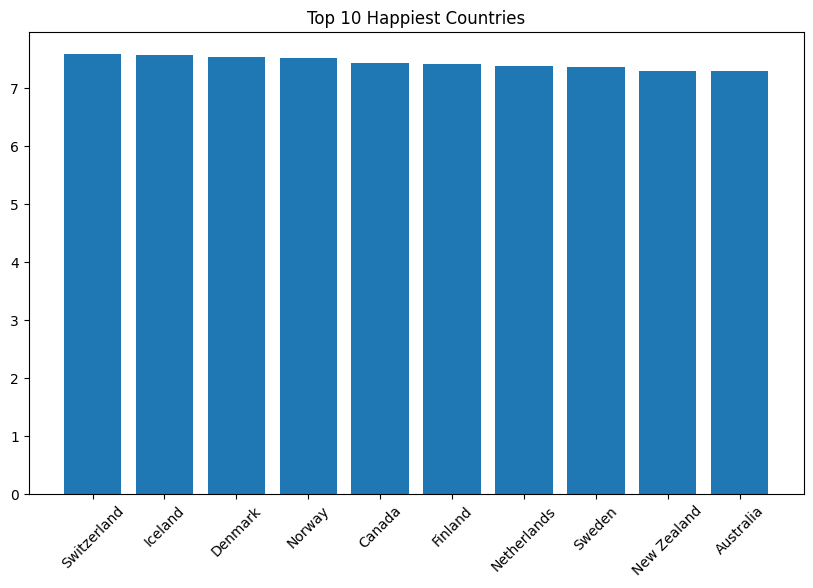

In [25]:
top10 = data.sort_values(by='Happiness Score', ascending=False).head(10)
plt.figure(figsize=(10,6))
plt.bar(top10['Country'], top10['Happiness Score'])
plt.xticks(rotation=45)
plt.title("Top 10 Happiest Countries")
plt.show()

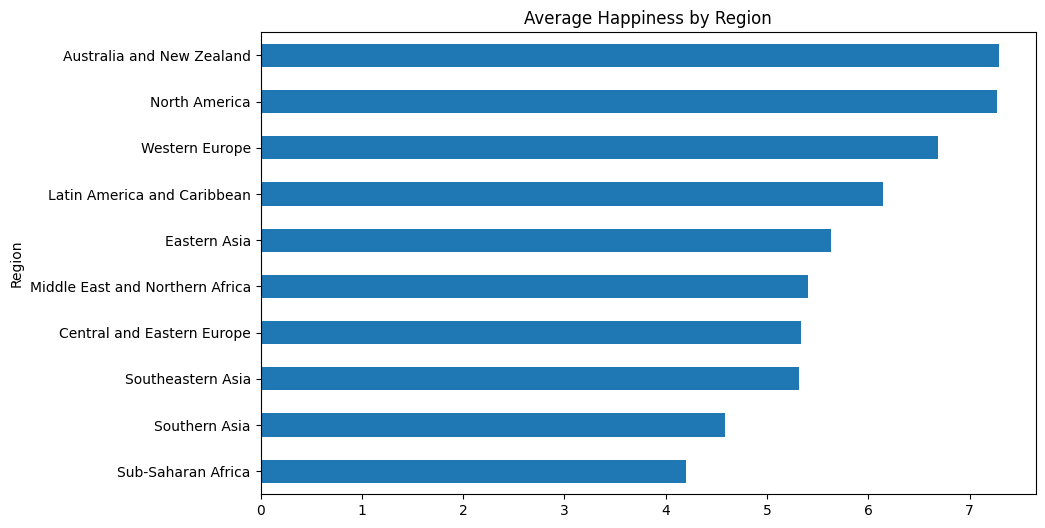

In [26]:
region_avg = data.groupby('Region')['Happiness Score'].mean().sort_values()
plt.figure(figsize=(10,6))
region_avg.plot(kind='barh')
plt.title("Average Happiness by Region")
plt.show()

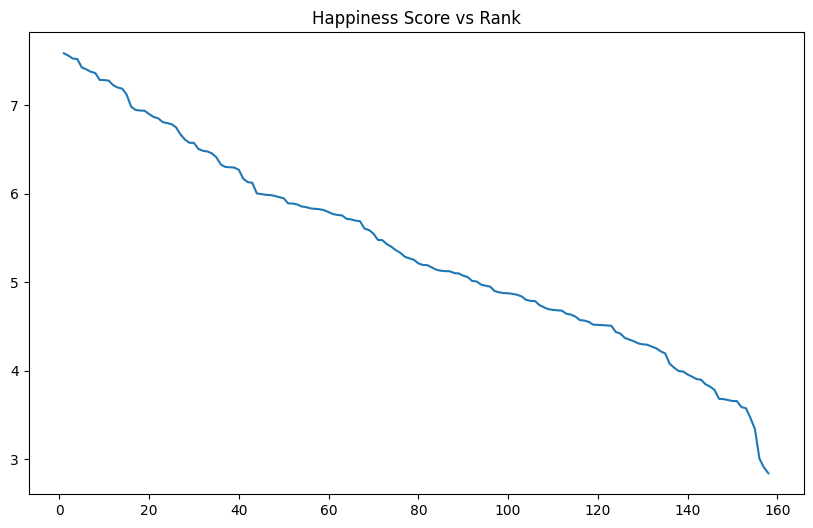

In [27]:
sorted_data = data.sort_values(by='Happiness Rank')
plt.figure(figsize=(10,6))
plt.plot(sorted_data['Happiness Rank'], sorted_data['Happiness Score'])
plt.title("Happiness Score vs Rank")
plt.show()

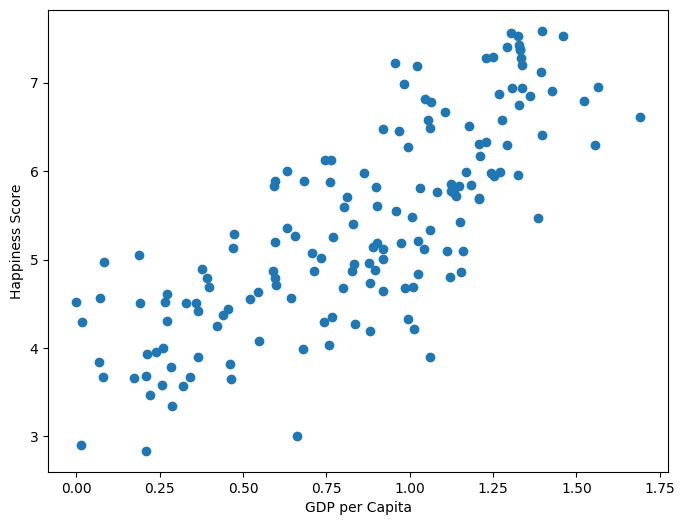

In [28]:
plt.figure(figsize=(8,6))
plt.scatter(data['Economy (GDP per Capita)'], data['Happiness Score'])
plt.xlabel("GDP per Capita")
plt.ylabel("Happiness Score")
plt.show()

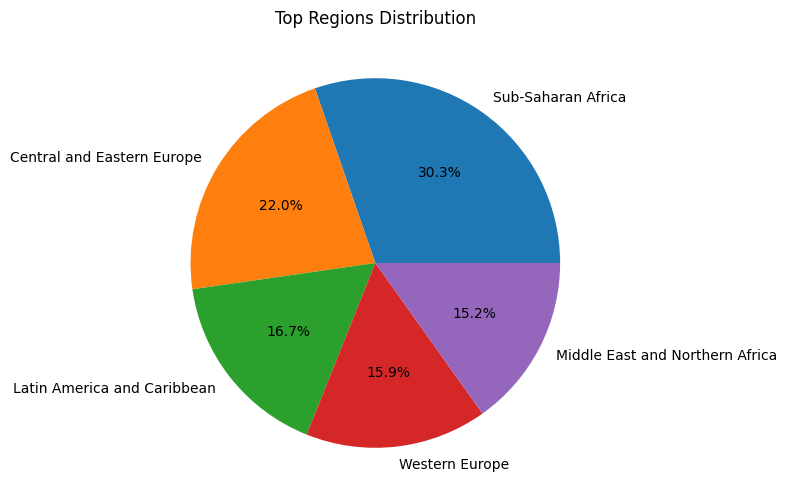

In [29]:
top_regions = data['Region'].value_counts().head(5)
plt.figure(figsize=(6,6))
plt.pie(top_regions, labels=top_regions.index, autopct='%1.1f%%')
plt.title("Top Regions Distribution")
plt.show()

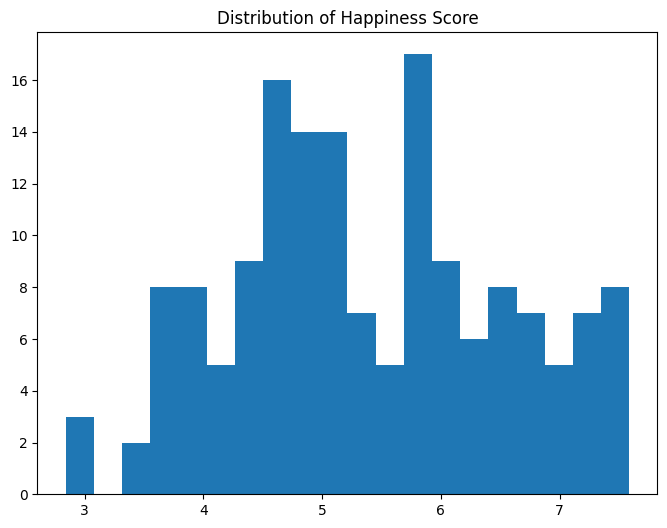

In [30]:
plt.figure(figsize=(8,6))
plt.hist(data['Happiness Score'], bins=20)
plt.title("Distribution of Happiness Score")
plt.show()